In [8]:
import os
import cv2            # OpenCV for general image processing
import numpy as np    # For numerical array manipulations
import pandas as pd   # To structure our final dataset
import mahotas        # Specifically for Haralick Texture features
from tqdm import tqdm # Progress bar for processing large datasets

In [9]:
def fd_hu_moments(image):
    """
    Extracts Shape Features using Hu Moments.
    These are invariant to image scale, rotation, and reflection.
    """
    # Convert image to grayscale as shape doesn't require color info
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Calculate moments and flatten the 2D result into a 1D array
    feature = cv2.HuMoments(cv2.moments(gray)).flatten()
    return feature

def fd_haralick(image):
    """
    Extracts Texture Features using Haralick's GLCM.
    Captures 'feel' of the leaf surface (smooth vs. grainy).
    """
    # Convert to grayscale to focus on pixel intensity relationships
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Calculate Haralick features and take the mean across 4 directions
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    return haralick

def fd_histogram(image):
    """
    Extracts Color Features using an HSV Histogram.
    Uses HSV (Hue, Saturation, Value) as it's more robust to lighting.
    """
    # Convert BGR (OpenCV default) to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Calculate a 3D histogram with 8 bins per channel (8*8*8 = 512 features)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    # Normalize the histogram so image size doesn't skew the data
    cv2.normalize(hist, hist)
    return hist.flatten()

print("Extraction functions are compiled and ready")

Extraction functions are compiled and ready


In [10]:
# ==========================================
# 3. DATA DISCOVERY & STRATIFIED SPLITTING
# ==========================================
from sklearn.model_selection import train_test_split

train_path = r"D:\archive\PlantVillage" # Your dataset root folder

# Get the list of all folder names (these are our plant disease classes)
train_labels = os.listdir(train_path)

# Filter out any hidden files like .DS_Store or desktop.ini
train_labels = [f for f in train_labels if os.path.isdir(os.path.join(train_path, f))]

image_paths = []
image_labels = []

print("Gathering image paths...")
for label in train_labels:
    dir_path = os.path.join(train_path, label)
    # Get all image files in this class folder
    files = [f for f in os.listdir(dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    for file in files:
        image_paths.append(os.path.join(dir_path, file))
        image_labels.append(label)

print(f"Total Images Found: {len(image_paths)}")

# --- THE CRITICAL SPLIT ---
# We split the PATHS, not the features, to ensure zero leakage.
# Using 'stratify' ensures training and testing have the same percentage of each disease.
train_paths, test_paths, y_train_labels, y_test_labels = train_test_split(
    image_paths, 
    image_labels, 
    test_size=0.20,       # 20% for testing
    random_state=42,      # For reproducibility
    stratify=image_labels # Keep class distribution balanced
)

print(f"Training set: {len(train_paths)} images")
print(f"Testing set: {len(test_paths)} images")

Gathering image paths...
Total Images Found: 20638
Training set: 16510 images
Testing set: 4128 images


In [11]:
# ==========================================
# 4. EXECUTING FEATURE EXTRACTION
# ==========================================

def extract_features(path_list):
    """Loop through paths, extract features, and return a feature matrix."""
    features_list = []
    
    # tqdm creates a progress bar to track how many images have been processed
    for path in tqdm(path_list, desc="Extracting Features"):
        # Load the image
        image = cv2.imread(path)
        
        # In case an image is corrupted or missing
        if image is None:
            continue
            
        # Resize to a standard size to ensure feature consistency
        # Fixed size 256x256 is common for PlantVillage
        image = cv2.resize(image, (256, 256))
        
        # Global Feature Extraction
        fv_hu_moments = fd_hu_moments(image)
        fv_haralick   = fd_haralick(image)
        fv_histogram  = fd_histogram(image)

        # Concatenate into one single feature vector
        # Total size: 7 + 13 + 512 = 532 features
        feature_vector = np.hstack([fv_histogram, fv_haralick, fv_hu_moments])
        
        features_list.append(feature_vector)
        
    return np.array(features_list)

print("Starting extraction for Training Set...")
X_train = extract_features(train_paths)

print("\nStarting extraction for Testing Set...")
X_test = extract_features(test_paths)

print(f"\nFinal Training Matrix Shape: {X_train.shape}")
print(f"Final Testing Matrix Shape: {X_test.shape}")

Starting extraction for Training Set...


Extracting Features: 100%|██████████| 16510/16510 [05:53<00:00, 46.75it/s]



Starting extraction for Testing Set...


Extracting Features: 100%|██████████| 4128/4128 [01:22<00:00, 50.18it/s]


Final Training Matrix Shape: (16510, 532)
Final Testing Matrix Shape: (4128, 532)


Total features extracted per image: 532
NaNs in Training Data: 0
NaNs in Testing Data: 0


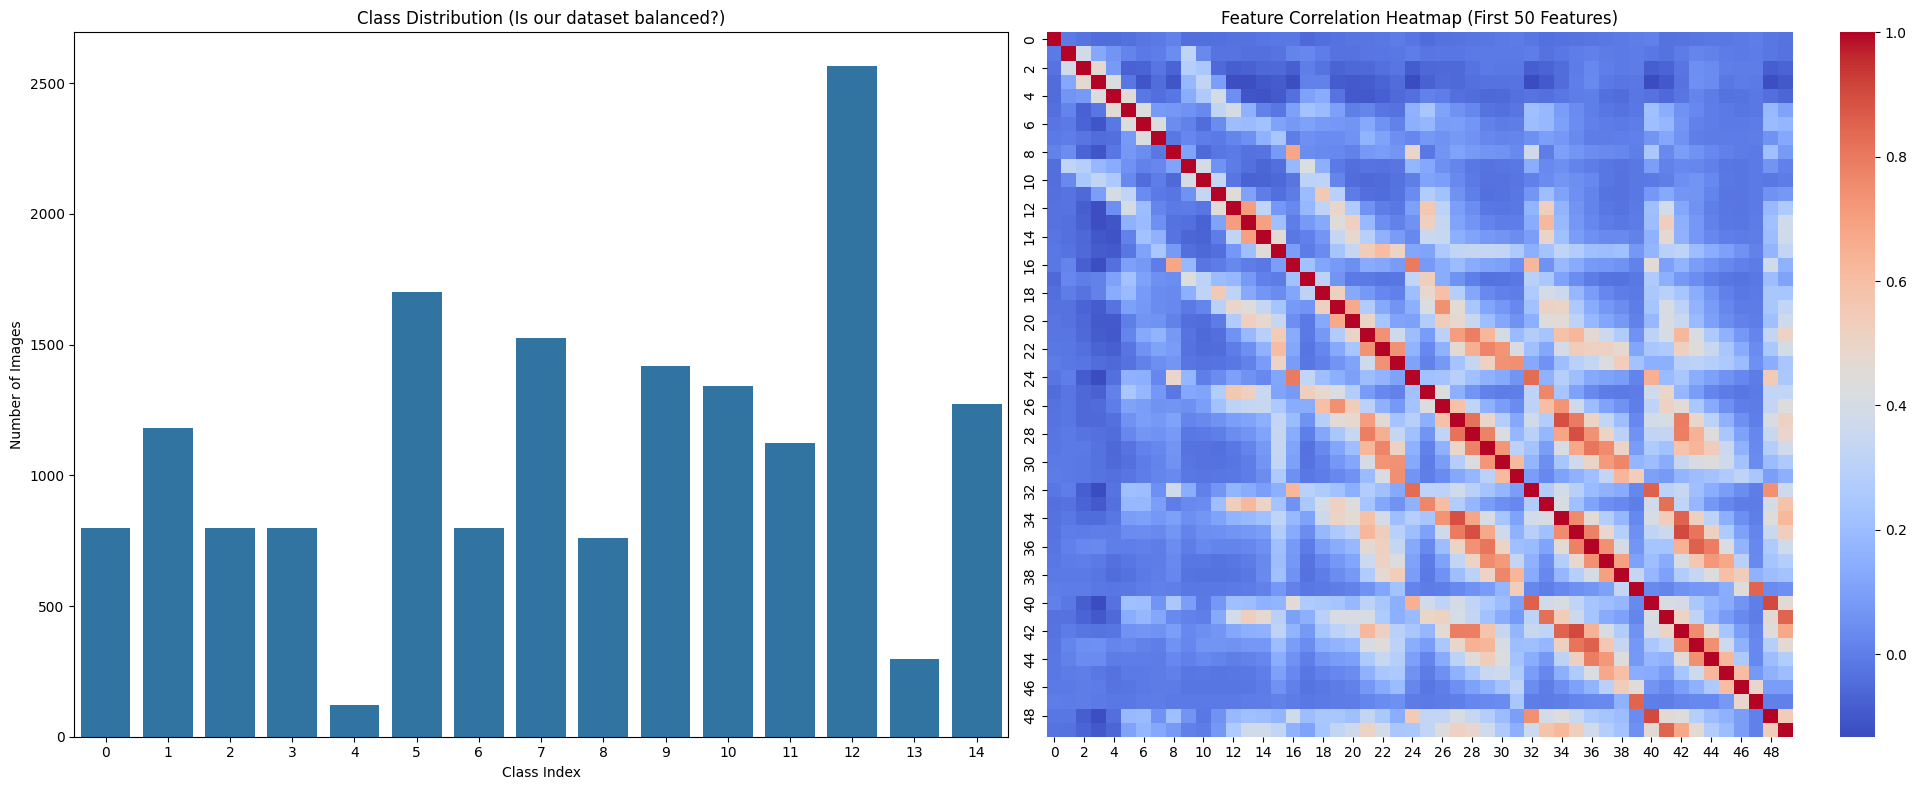

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 5. LABEL ENCODING & CLEANING
# ==========================================

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 5. LABEL ENCODING & CLEANING
# ==========================================

# Initialize the encoder
le = LabelEncoder()

# Fit and transform the labels to integers
# y_train_labels and y_test_labels were created in our Step 2 split
y_train = le.fit_transform(y_train_labels)
y_test  = le.transform(y_test_labels)

# Check for missing values in the extracted features
nan_count_train = np.isnan(X_train).sum()
nan_count_test = np.isnan(X_test).sum()

print(f"Total features extracted per image: {X_train.shape[1]}")
print(f"NaNs in Training Data: {nan_count_train}")
print(f"NaNs in Testing Data: {nan_count_test}")

# If NaNs exist, we handle them immediately
if nan_count_train > 0 or nan_count_test > 0:
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)
    print("Notice: NaNs were found and handled using Mean Imputation.")

# ==========================================
# 6. NON-REPETITIVE EDA VISUALIZATIONS
# ==========================================

def perform_eda(X, y, labels):
    plt.figure(figsize=(20, 8))
    
    # Plot 1: Class Distribution
    plt.subplot(1, 2, 1)
    sns.countplot(x=y)
    plt.title("Class Distribution (Is our dataset balanced?)")
    plt.xlabel("Class Index")
    plt.ylabel("Number of Images")
    
    # Plot 2: Correlation Heatmap (Sampling 50 features for readability)
    plt.subplot(1, 2, 2)
    # We take a subset because 532 features would make the heatmap a black blob
    correlation_matrix = pd.DataFrame(X[:, :50]).corr()
    sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
    plt.title("Feature Correlation Heatmap (First 50 Features)")
    
    plt.tight_layout()
    plt.show()

# Run the EDA
perform_eda(X_train, y_train, train_labels)

In [14]:
# ==========================================
# 7. SCALING & DIMENSIONALITY REDUCTION
# ==========================================

# 1. Standardize features (Mean=0, Variance=1)
# Important: Fit on TRAIN, transform both TRAIN and TEST
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Apply PCA
# We want to keep 95% of the information (variance)
pca = PCA(n_components=0.95, svd_solver='full')

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original feature count: {X_train.shape[1]}")
print(f"Reduced feature count (95% variance): {X_train_pca.shape[1]}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

Original feature count: 532
Reduced feature count (95% variance): 171
Total variance captured: 95.01%


In [15]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 8. HYPERPARAMETER TUNING (RANDOMIZED)
# ==========================================

# Define the parameter grid
param_dist = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf'] # RBF is generally best for image features
}

# Initialize the SVM model
svm_model = SVC()

# Set up Randomized Search with 3-fold cross-validation
# n_iter=5 means it will try 5 random combinations
random_search = RandomizedSearchCV(
    svm_model, 
    param_distributions=param_dist, 
    n_iter=5, 
    cv=3, 
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

print("Starting Hyperparameter Tuning...")
random_search.fit(X_train_pca, y_train)

# Get the best model
best_svm = random_search.best_estimator_

print(f"\nBest Parameters Found: {random_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters Found: {'kernel': 'rbf', 'gamma': 0.01, 'C': 100}


Final Model Accuracy: 93.68%
------------------------------
Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.90      0.92       199
                     Pepper__bell___healthy       0.96      0.92      0.94       296
                      Potato___Early_blight       0.97      0.91      0.94       200
                       Potato___Late_blight       0.98      0.89      0.93       200
                           Potato___healthy       0.96      0.73      0.83        30
                      Tomato_Bacterial_spot       0.99      0.95      0.97       426
                        Tomato_Early_blight       0.94      0.91      0.93       200
                         Tomato_Late_blight       0.91      0.93      0.92       382
                           Tomato_Leaf_Mold       0.98      0.87      0.92       190
                  Tomato_Septoria_leaf_spot       0.95   

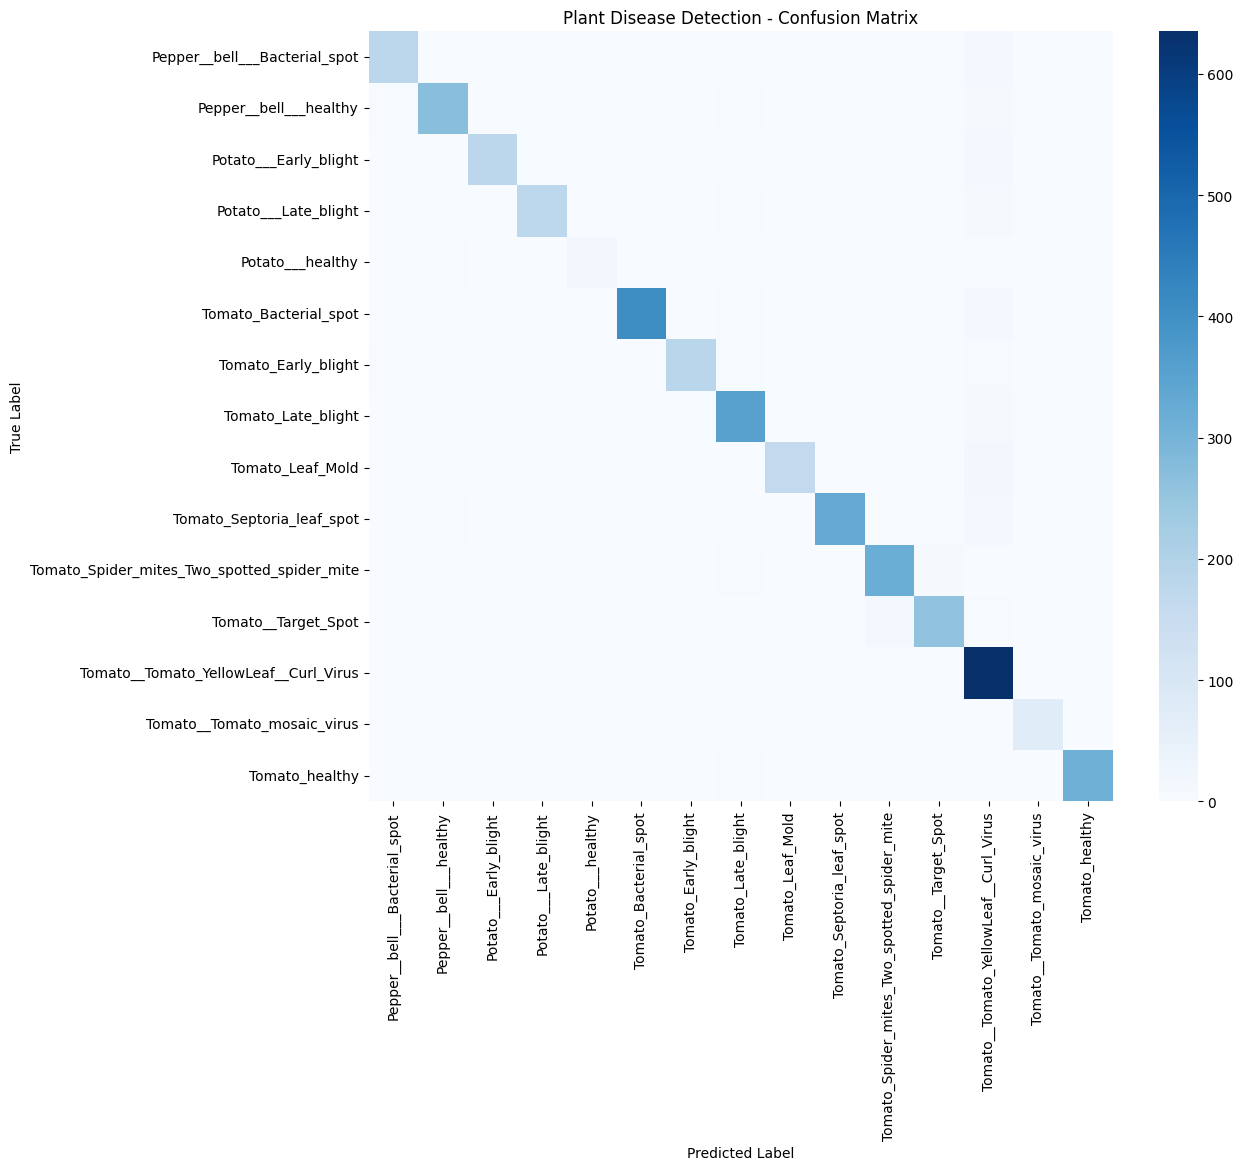

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Make predictions on the scaled, PCA-transformed test data
y_pred = best_svm.predict(X_test_pca)

# 2. Calculate Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

# 3. Detailed Classification Report
# We use target_names=le.classes_ to see the actual disease names
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Visualization: Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Plant Disease Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [17]:
def predict_plant_disease(image_path):
    """
    The final 'Production' function to predict a disease from a raw image path.
    """
    # 1. Load and Preprocess
    img = cv2.imread(image_path)
    img = cv2.resize(img, (256, 256))
    
    # 2. Extract Features (Same logic as training)
    feat_hu = fd_hu_moments(img)
    feat_haralick = fd_haralick(img)
    feat_hist = fd_histogram(img)
    
    # 3. Combine and Reshape for a single sample
    final_feature = np.hstack([feat_hist, feat_haralick, feat_hu]).reshape(1, -1)
    
    # 4. Apply the exact same Scaler and PCA we trained earlier
    scaled_feature = scaler.transform(final_feature)
    pca_feature = pca.transform(scaled_feature)
    
    # 5. Predict
    prediction = best_svm.predict(pca_feature)
    result_label = le.inverse_transform(prediction)[0]
    
    return result_label

# Test it on a random image from your test set
test_img = test_paths[94]
print(f"Testing Inference on: {test_img}")
print(f"Predicted Result: {predict_plant_disease(test_img)}")
print(f"Actual Label: {y_test_labels[94]}")

Testing Inference on: D:\archive\PlantVillage\Tomato_Late_blight\e93721af-a478-4021-8d9a-bffdc1ba7c45___RS_Late.B 5050.JPG
Predicted Result: Tomato_Late_blight
Actual Label: Tomato_Late_blight


In [18]:
import joblib
import os

# Define the absolute path to your Desktop
desktop_path = r'C:\Users\Elzoz\Desktop\plant_disease_model.pkl'

# Your components
model_export = {
    'svm_model': best_svm,
    'scaler': scaler,
    'pca': pca,
    'label_encoder': le
}

# Save using the absolute path
try:
    joblib.dump(model_export, desktop_path)
    print(f"✅ SUCCESS! Model saved directly to: {desktop_path}")
    
    # Final sanity check: does the file exist now?
    if os.path.exists(desktop_path):
        print("📁 I can see the file on your Desktop. You are good to go!")
except Exception as e:
    print(f"❌ Failed to save: {e}")

✅ SUCCESS! Model saved directly to: C:\Users\Elzoz\Desktop\plant_disease_model.pkl
📁 I can see the file on your Desktop. You are good to go!


In [21]:
from flask import Flask, request, jsonify
import joblib
import cv2
import numpy as np
import mahotas

app = Flask(__name__)

# 1. Load the "Engine" (Everything we saved in Step 8)
data = joblib.load('plant_disease_model.pkl')
model = data['svm_model']
scaler = data['scaler']
pca = data['pca']
le = data['label_encoder']

# 2. Feature Extraction Functions (Must be identical to training!)
def extract_features(image):
    image = cv2.resize(image, (256, 256))
    
    # Hu Moments
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hu = cv2.HuMoments(cv2.moments(gray)).flatten()
    
    # Haralick
    haralick = mahotas.features.haralick(gray).mean(axis=0)
    
    # Histogram
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    hist = hist.flatten()
    
    return np.hstack([hist, haralick, hu]).reshape(1, -1)

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400
    
    # Read image from Flutter
    file = request.files['file']
    img_bytes = np.frombuffer(file.read(), np.uint8)
    img = cv2.imdecode(img_bytes, cv2.IMREAD_COLOR)
    
    # Process
    features = extract_features(img)
    scaled_features = scaler.transform(features)
    pca_features = pca.transform(scaled_features)
    
    # Predict
    prediction = model.predict(pca_features)
    disease = le.inverse_transform(prediction)[0]
    
    return jsonify({'disease': disease})

if __name__ == '__main__':
    # Use 0.0.0.0 so your phone/emulator can see the server
    app.run(host='0.0.0.0', port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://10.33.255.71:5000
Press CTRL+C to quit
10.33.255.71 - - [21/Apr/2026 20:37:38] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:38:25] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:38:29] "POST /predict HTTP/1.1" 200 -
10.33.255.71 - - [21/Apr/2026 20:39:21] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [21/Apr/2026 20:39:24] "GET / HTTP/1.1" 404 -
127.0.0.1 - - [21/Apr/2026 20:39:25] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [21/Apr/2026 20:40:57] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:41:32] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:43:03] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:43:05] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:43:11] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [21/Apr/2026 20:43:21] "POST /predict HTTP/1.1" 200 -
